# Week 8 / Stage 4 — Automatic Safe Step Selection alpha

## What it does
- loads the Week 5 VAE + digit classifier + thickness probe
- rebuilds the **global** and **local** steering families
- evaluates fixed-step baselines
- chooses a per-sample safe step \(\alpha^*\) from a small discrete grid
- compares **fixed alpha** vs **automatic \(\alpha^*\)** under content-preservation budgets
- saves CSV tables, plots, and `memo_week8.md`


---
Stage 4: Automatic safe step selection alpha*
------------------------------------------------------------
Why:
  Fixed steering steps work only on average. Some samples need a small edit,
  others tolerate a larger one. A single global alpha therefore causes either
  under-editing or content breakage.

What this script does:
  1) rebuild global + local steering families,
  2) evaluate fixed-alpha baselines,
  3) choose alpha* per sample from a small discrete grid,
  4) enforce safe constraints via feature drift / confidence / digit-consistency,
  5) compare fixed-step vs automatic alpha* and save the weekly package.

How:
  for each sample, family, and budget tau we scan alpha_grid in ascending order,
  stop early when penalties exceed thresholds, and keep the feasible alpha that
  maximizes target_gain - lambda_feat * feat_penalty - lambda_conf * conf_drop.

For what:
  This implements the next project stage: reliable steering with automatic,
  constraint-based step choice instead of one fixed traversal magnitude.

In [1]:
%pip install -q torch torchvision matplotlib pandas tqdm scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import os
import json
import time
import random
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from sklearn.cluster import MiniBatchKMeans


from IPython.display import display, Image


In [ ]:
# Fill these paths manually
cfg: Dict[str, Any] = {
    "seed": 42,
    "device": "cuda",

    "artifacts": {
        "week5_config_json": "../week5/output/kaggle/working/runs/20260224_074746_week5/config.json",
        "vae_checkpoint": "../week5/output/kaggle/working/runs/20260224_074746_week5/checkpoints/vae_epoch020.pt",
        "digit_classifier_checkpoint": "../week5/output/kaggle/working/runs/20260224_074746_week5/checkpoints/clf_best.pt",
        "thickness_probe_checkpoint": "../week5/output/kaggle/working/runs/20260224_074746_week5/checkpoints/probe_best.pt",
    },

    "run": {
        "root": "runs",
        "tag": "week8_safe_alpha",
    },

    "data": {
        "mnist_root": "../output/kaggle/working/data/MNIST/raw",
        "batch_size": 128,
        "num_workers": 0,
        "subset": None,
    },

    "probe": {
        "aug": {
            "thin_k": 1,
            "thick_k": 1,
            "blend": 0.2,
        }
    },

    "cluster": {
        "k_values": [2, 4, 8, 16],
        "fit_max_points": 25000,
        "direction_max_batches": 250,
        "min_cluster_points": 32,
        "mbk_batch_size": 2048,
    },

    "steer": {
        "fixed_alphas": [0.5, 1.0, 2.0],
        "alpha_grid": [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0, 4.0],
        "preview_n": 8,
        "curve_n": 6,
    },

    "safe": {
        "tau_feat_values": [2.0, 3.5, 5.0],
        "tau_conf": 0.20,
        "lambda_feat": 0.15,
        "lambda_conf": 1.00,
        "strict_digit_consistency": True,
        "early_stop_multiplier": 1.15,
        "stop_on_digit_mismatch": True,
    },
}




In [ ]:
# ------------------------ helpers ------------------------
def get_device(name: str) -> torch.device:
    if name == "cuda" and torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id: int):
    worker_seed = (torch.initial_seed() + worker_id) % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def save_json(path: str, obj: dict) -> None:
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def make_run_dir(root: str, tag: str) -> str:
    ts = time.strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(root, f"{ts}_{tag}")
    os.makedirs(os.path.join(run_dir, "plots"), exist_ok=False)
    os.makedirs(os.path.join(run_dir, "checkpoints"), exist_ok=True)
    return run_dir

def require_existing_file(path: str, name: str) -> str:
    if not isinstance(path, str) or not path.strip() or "TODO/" in path:
        raise ValueError(f"Fill cfg with a real path for: {name}")
    if not os.path.isfile(path):
        raise FileNotFoundError(f"{name} was not found: {path}")
    return path

def prepare_dir_path(path: str, name: str) -> str:
    if not isinstance(path, str) or not path.strip() or "TODO/" in path:
        raise ValueError(f"Fill cfg with a real path for: {name}")
    os.makedirs(path, exist_ok=True)
    return path


# ------------------------ data ------------------------
def get_mnist_loaders(data_root: str, batch_size: int, num_workers: int, subset: Optional[int] = None):
    # keep torchvision import local, so the module can still be imported in environments
    # where torchvision is not preloaded correctly.
    from torchvision import datasets, transforms

    tfm = transforms.ToTensor()

    train_ds = datasets.MNIST(root=data_root, train=True, download=True, transform=tfm)
    test_ds = datasets.MNIST(root=data_root, train=False, download=True, transform=tfm)

    if subset is not None:
        train_ds = Subset(train_ds, list(range(int(subset))))

    g = torch.Generator()
    g.manual_seed(int(cfg["seed"]))

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=g,
    )
    return train_loader, test_loader


In [ ]:
# ------------------------ models from prev weeks ------------------------
class ConvEncoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(inplace=True),
        )
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_lv = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        h = self.net(x).flatten(1)
        return self.fc_mu(h), self.fc_lv(h)


class ConvDecoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
        )

    def forward(self, z):
        h = self.fc(z).view(z.size(0), 64, 7, 7)
        return self.net(h)


class ConvVAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.enc = ConvEncoder(latent_dim)
        self.dec = ConvDecoder(latent_dim)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, lv = self.enc(x)
        z = self.reparam(mu, lv)
        x_logits = self.dec(z)
        return x_logits, mu, lv


class DigitCNN(nn.Module):
    def __init__(self, feat_dim: int = 128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.fc1 = nn.Linear(64 * 7 * 7, feat_dim)
        self.fc2 = nn.Linear(feat_dim, 10)

    def forward(self, x, return_feat: bool = False):
        h = self.conv(x).flatten(1)
        feat = F.relu(self.fc1(h))
        logits = self.fc2(feat)
        return (logits, feat) if return_feat else logits


class ThicknessProbe(nn.Module):
    def __init__(self, in_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2),
        )

    def forward(self, feat):
        return self.net(feat)


In [ ]:
# ------------------------ image/latent utilities ------------------------
def gray_dilate(x: torch.Tensor, iters: int = 1, k: int = 3) -> torch.Tensor:
    out = x
    pad = k // 2
    for _ in range(iters):
        out = F.max_pool2d(out, kernel_size=k, stride=1, padding=pad)
    return out

def gray_erode(x: torch.Tensor, iters: int = 1, k: int = 3) -> torch.Tensor:
    out = x
    pad = k // 2
    for _ in range(iters):
        out = -F.max_pool2d(-out, kernel_size=k, stride=1, padding=pad)
    return out

@torch.no_grad()
def thickness_transform(x: torch.Tensor, mode: str, iters: int, blend: float = 0.2) -> torch.Tensor:
    if mode == "thick":
        out = gray_dilate(x, iters=iters, k=3)
    elif mode == "thin":
        out = gray_erode(x, iters=iters, k=3)
    else:
        raise ValueError("mode must be 'thin' or 'thick'")

    eps = 1e-6
    out = out / (out.amax(dim=(1, 2, 3), keepdim=True) + eps)
    out = (1.0 - blend) * out + blend * x
    return out.clamp(0.0, 1.0)

@torch.no_grad()
def encode_mu(vae: nn.Module, x: torch.Tensor) -> torch.Tensor:
    mu, _ = vae.enc(x)
    return mu

@torch.no_grad()
def decode_sigmoid(vae: nn.Module, z: torch.Tensor) -> torch.Tensor:
    return torch.sigmoid(vae.dec(z))

@torch.no_grad()
def clf_logits_and_feat(clf: nn.Module, x: torch.Tensor):
    return clf(x, return_feat=True)

@torch.no_grad()
def probe_logits_on_imgs(clf: nn.Module, probe: nn.Module, x: torch.Tensor) -> torch.Tensor:
    _, feat = clf_logits_and_feat(clf, x)
    return probe(feat)

@torch.no_grad()
def feature_l2_on_feats(feat_a: torch.Tensor, feat_b: torch.Tensor) -> torch.Tensor:
    return ((feat_a - feat_b) ** 2).sum(dim=1).sqrt()

@torch.no_grad()
def mean_ink(x: torch.Tensor) -> torch.Tensor:
    return x.mean(dim=(1, 2, 3))


In [ ]:
# ------------------------ family construction (from week 7) ------------------------
def normalize_direction(
        d: np.ndarray, 
        eps: float = 1e-8
    ) -> np.ndarray:
    # Normalize direction to unit length
    n = float(np.linalg.norm(d))
    if n < eps:
        return d.astype(np.float32)
    return (d / n).astype(np.float32)

@torch.no_grad()
def extract_train_latents_and_deltas(
        vae: nn.Module,
        loader: DataLoader,
        thin_k: int,
        thick_k: int,
        blend: float,
        max_batches: Optional[int],
        device: torch.device,
    ) -> Dict[str, np.ndarray]:
    # Z = base latents, D = thick-thin latent deltas, Y = digit labels
    zs, deltas, ys = [], [], []
    ink_gap_sum = 0.0
    ink_n = 0

    for bi, (x, y) in enumerate(loader):
        # Optional speed-up: use only first max_batches
        if max_batches is not None and bi >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)

        # Build paired thin/thick versions of each image
        x_thin = thickness_transform(x, mode="thin", iters=thin_k, blend=blend)
        x_thick = thickness_transform(x, mode="thick", iters=thick_k, blend=blend)

        # Encode original / thin / thick images into latent means
        z = encode_mu(vae, x)
        z_thin = encode_mu(vae, x_thin)
        z_thick = encode_mu(vae, x_thick)

        # Store base latent and local attribute direction delta
        zs.append(z.detach().cpu().numpy())
        deltas.append((z_thick - z_thin).detach().cpu().numpy())
        ys.append(y.detach().cpu().numpy())

        # Diagnostic: thick should contain more ink than thin
        ink_gap_sum += (mean_ink(x_thick) - mean_ink(x_thin)).sum().item()
        ink_n += x.size(0)

    # Merge all batches into full train arrays
    Z = np.concatenate(zs, axis=0)
    D = np.concatenate(deltas, axis=0)
    Y = np.concatenate(ys, axis=0)

    return {
        "Z": Z.astype(np.float32),
        "D": D.astype(np.float32),
        "Y": Y.astype(np.int64),
        "ink_gap_mean": float(ink_gap_sum / max(1, ink_n)),
    }

def maybe_subsample(
        X: np.ndarray, 
        max_points: Optional[int], 
        seed: int
    ) -> np.ndarray:
    # Use all points unless subsampling is requested
    if max_points is None or len(X) <= int(max_points):
        return np.arange(len(X))
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), size=int(max_points), replace=False)
    return np.sort(idx)

def fit_global_and_local_direction_families(
        Z: np.ndarray,
        D: np.ndarray,
        k_values: List[int],
        fit_max_points: Optional[int],
        min_cluster_points: int,
        seed: int,
        mbk_batch_size: int,
    ) -> Tuple[Dict[str, Any], pd.DataFrame]:
    # Global direction = normalized mean delta over all samples
    global_dir = normalize_direction(D.mean(axis=0))
    latent_dim = Z.shape[1]

    families: Dict[str, Any] = {
        "global": {
            "type": "global",
            "name": "global",
            "direction": global_dir,
            "latent_dim": latent_dim,
            "num_points": int(len(Z)),
        }
    }

    # Cluster-level diagnostics
    cluster_rows = []

    # Optionally fit k-means on a subset for speed
    fit_idx = maybe_subsample(Z, fit_max_points, seed=seed)
    Z_fit = Z[fit_idx]

    for K in k_values:
        # Learn K latent clusters
        km = MiniBatchKMeans(
            n_clusters=int(K),
            random_state=int(seed),
            batch_size=int(mbk_batch_size),
            n_init="auto",
        )
        km.fit(Z_fit)

        # Assign every train point to a cluster
        assign = km.predict(Z)

        # dirs[k] = local direction for cluster k
        dirs = np.zeros((int(K), latent_dim), dtype=np.float32)
        counts = np.zeros(int(K), dtype=np.int64)
        fallback_count = 0

        for k in range(int(K)):
            mask = assign == k
            n_k = int(mask.sum())
            counts[k] = n_k

            # Too-small clusters fall back to global direction
            if n_k < int(min_cluster_points):
                dirs[k] = global_dir
                fallback_count += 1
            else:
                # Local direction = mean delta inside this cluster
                d_k = D[mask].mean(axis=0)

                # Near-zero local direction also falls back to global
                if float(np.linalg.norm(d_k)) < 1e-8:
                    dirs[k] = global_dir
                    fallback_count += 1
                else:
                    dirs[k] = normalize_direction(d_k)

            # Save cluster stats for analysis
            cluster_rows.append(
                {
                    "K": int(K),
                    "cluster": int(k),
                    "n_points": n_k,
                    "direction_norm": float(np.linalg.norm(dirs[k])),
                    "used_global_fallback": int(n_k < int(min_cluster_points)),
                }
            )

        # Store local family for this K
        families[f"local_k{K}"] = {
            "type": "local",
            "name": f"local_k{K}",
            "K": int(K),
            "kmeans": km,
            "directions": dirs,
            "cluster_sizes": counts,
            "fallback_count": int(fallback_count),
            "latent_dim": latent_dim,
            "num_points": int(len(Z)),
        }

    return families, pd.DataFrame(cluster_rows)

def direction_batch_for_family(
        family: Dict[str, Any], 
        z_batch: torch.Tensor
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
    # Global family: same direction for every sample
    if family["type"] == "global":
        d = torch.from_numpy(family["direction"]).to(z_batch.device).unsqueeze(0).expand_as(z_batch)
        return d, None

    # Local family: choose cluster-specific direction per sample
    z_np = z_batch.detach().cpu().numpy()
    cluster_ids = family["kmeans"].predict(z_np)
    dirs_np = family["directions"][cluster_ids]
    return torch.from_numpy(dirs_np).to(z_batch.device), torch.from_numpy(cluster_ids).to(z_batch.device)


# ------------------------ evaluation core ------------------------
@torch.no_grad()
def evaluate_fixed_policy(
        vae: nn.Module,
        clf: nn.Module,
        probe: nn.Module,
        loader: DataLoader,
        families: Dict[str, Any],
        fixed_alphas: List[float],
        tau_feat_values: List[float],
        tau_conf: float,
        device: torch.device,
    ) -> pd.DataFrame:
    # Evaluate one shared alpha for all samples
    rows = []

    for family_name, family in families.items():
        for alpha_fixed in fixed_alphas:
            # Separate aggregates for each feature-drift budget tau_feat
            agg = {
                tau: {
                    "n": 0,
                    "digit_acc_sum": 0.0,
                    "digit_cons_sum": 0.0,
                    "probe_margin_sum": 0.0,
                    "probe_gain_sum": 0.0,
                    "feat_l2_sum": 0.0,
                    "conf_drop_sum": 0.0,
                    "feasible_sum": 0.0,
                }
                for tau in tau_feat_values
            }

            for x, y in loader:
                x = x.to(device)
                y = y.to(device)

                # Base latent and plain reconstruction
                z = encode_mu(vae, x)
                x_rec = decode_sigmoid(vae, z)

                # Reconstruction acts as the reference content state
                logits_rec, feat_rec = clf_logits_and_feat(clf, x_rec)
                pred_rec = logits_rec.argmax(dim=1)
                prob_rec = torch.softmax(logits_rec, dim=1)
                conf_rec = prob_rec.gather(1, pred_rec[:, None]).squeeze(1)
                probe_rec = probe(feat_rec)
                margin_rec = probe_rec[:, 1] - probe_rec[:, 0]

                # Apply one fixed steering step
                d_batch, _ = direction_batch_for_family(family, z)
                x_a = decode_sigmoid(vae, z + float(alpha_fixed) * d_batch)

                # Measure edited sample
                logits_a, feat_a = clf_logits_and_feat(clf, x_a)
                pred_a = logits_a.argmax(dim=1)
                prob_a = torch.softmax(logits_a, dim=1)
                conf_a_on_rec = prob_a.gather(1, pred_rec[:, None]).squeeze(1)
                probe_a = probe(feat_a)
                margin_a = probe_a[:, 1] - probe_a[:, 0]

                # Content-preservation proxies
                feat_l2 = feature_l2_on_feats(feat_rec, feat_a)
                conf_drop = (conf_rec - conf_a_on_rec).clamp_min(0.0)

                # Main outcome metrics
                digit_acc = (pred_a == y).float()
                digit_cons = (pred_a == pred_rec).float()
                probe_gain = margin_a - margin_rec

                for tau in tau_feat_values:
                    # Feasible = stays within feature/confidence budgets and keeps class
                    feasible = (feat_l2 <= float(tau)) & (conf_drop <= float(tau_conf)) & (pred_a == pred_rec)
                    st = agg[tau]
                    st["n"] += x.size(0)
                    st["digit_acc_sum"] += float(digit_acc.sum().item())
                    st["digit_cons_sum"] += float(digit_cons.sum().item())
                    st["probe_margin_sum"] += float(margin_a.sum().item())
                    st["probe_gain_sum"] += float(probe_gain.sum().item())
                    st["feat_l2_sum"] += float(feat_l2.sum().item())
                    st["conf_drop_sum"] += float(conf_drop.sum().item())
                    st["feasible_sum"] += float(feasible.float().sum().item())

            for tau in tau_feat_values:
                # Final mean metrics for this family x fixed_alpha x tau
                st = agg[tau]
                n = max(1, int(st["n"]))
                rows.append(
                    {
                        "policy": "fixed",
                        "family": family_name,
                        "family_type": family["type"],
                        "K": int(family.get("K", 0)),
                        "tau_feat": float(tau),
                        "tau_conf": float(tau_conf),
                        "fixed_alpha": float(alpha_fixed),
                        "digit_acc": st["digit_acc_sum"] / n,
                        "digit_consistency": st["digit_cons_sum"] / n,
                        "probe_margin": st["probe_margin_sum"] / n,
                        "probe_margin_gain": st["probe_gain_sum"] / n,
                        "feat_l2_to_recon": st["feat_l2_sum"] / n,
                        "class_conf_drop": st["conf_drop_sum"] / n,
                        "feasible_rate": st["feasible_sum"] / n,
                    }
                )

    return pd.DataFrame(rows).sort_values(["family", "tau_feat", "fixed_alpha"]).reset_index(drop=True)


@torch.no_grad()
def choose_alpha_star_batch(
        vae: nn.Module,
        clf: nn.Module,
        probe: nn.Module,
        z: torch.Tensor,
        y: torch.Tensor,
        family: Dict[str, Any],
        alpha_grid: List[float],
        tau_feat: float,
        tau_conf: float,
        lambda_feat: float,
        lambda_conf: float,
        strict_digit_consistency: bool,
        early_stop_multiplier: float,
        stop_on_digit_mismatch: bool,
    ) -> Dict[str, torch.Tensor]:
    # Reconstruction baseline for each sample
    x_rec = decode_sigmoid(vae, z)
    logits_rec, feat_rec = clf_logits_and_feat(clf, x_rec)
    pred_rec = logits_rec.argmax(dim=1)
    prob_rec = torch.softmax(logits_rec, dim=1)
    conf_rec = prob_rec.gather(1, pred_rec[:, None]).squeeze(1)
    probe_rec = probe(feat_rec)
    margin_rec = probe_rec[:, 1] - probe_rec[:, 0]
    digit_acc_rec = (pred_rec == y).float()

    # Get steering direction for each sample
    d_batch, cluster_ids = direction_batch_for_family(family, z)
    B = z.size(0)

    # Best-so-far values for each sample in the batch
    best_score = torch.zeros(B, device=z.device)
    best_alpha = torch.zeros(B, device=z.device)
    best_margin = margin_rec.clone()
    best_gain = torch.zeros(B, device=z.device)
    best_feat = torch.zeros(B, device=z.device)
    best_conf = torch.zeros(B, device=z.device)
    best_digit_acc = digit_acc_rec.clone()
    best_digit_cons = torch.ones(B, device=z.device)
    chosen_is_nonzero = torch.zeros(B, dtype=torch.bool, device=z.device)
    active = torch.ones(B, dtype=torch.bool, device=z.device)

    for alpha in alpha_grid:
        alpha = float(alpha)

        # Skip the trivial no-edit point
        if alpha <= 0:
            continue

        # Stop if no samples remain active
        if not bool(active.any()):
            break

        # Apply current candidate alpha
        x_a = decode_sigmoid(vae, z + alpha * d_batch)
        logits_a, feat_a = clf_logits_and_feat(clf, x_a)
        pred_a = logits_a.argmax(dim=1)
        prob_a = torch.softmax(logits_a, dim=1)
        conf_a_on_rec = prob_a.gather(1, pred_rec[:, None]).squeeze(1)
        probe_a = probe(feat_a)
        margin_a = probe_a[:, 1] - probe_a[:, 0]

        # Compute steering gain and side effects
        feat_l2 = feature_l2_on_feats(feat_rec, feat_a)
        conf_drop = (conf_rec - conf_a_on_rec).clamp_min(0.0)
        digit_acc = (pred_a == y).float()
        digit_cons = (pred_a == pred_rec)
        gain = margin_a - margin_rec

        # Hard feasibility constraints
        feasible = (feat_l2 <= float(tau_feat)) & (conf_drop <= float(tau_conf))
        if strict_digit_consistency:
            feasible = feasible & digit_cons

        # Soft objective: reward gain, penalize drift/confidence loss
        score = gain - float(lambda_feat) * feat_l2 - float(lambda_conf) * conf_drop
        better = active & feasible & (score > best_score)

        # Update best alpha* where current alpha is better
        best_score = torch.where(better, score, best_score)
        best_alpha = torch.where(better, torch.full_like(best_alpha, alpha), best_alpha)
        best_margin = torch.where(better, margin_a, best_margin)
        best_gain = torch.where(better, gain, best_gain)
        best_feat = torch.where(better, feat_l2, best_feat)
        best_conf = torch.where(better, conf_drop, best_conf)
        best_digit_acc = torch.where(better, digit_acc, best_digit_acc)
        best_digit_cons = torch.where(better, digit_cons.float(), best_digit_cons)
        chosen_is_nonzero = chosen_is_nonzero | better

        # Early-stop samples that already violate budgets too strongly
        violation = (feat_l2 > float(tau_feat) * float(early_stop_multiplier)) | (
            conf_drop > float(tau_conf) * float(early_stop_multiplier)
        )
        if stop_on_digit_mismatch and strict_digit_consistency:
            violation = violation | (~digit_cons)
        active = active & (~violation)

    return {
        "alpha_star": best_alpha,
        "digit_acc": best_digit_acc,
        "digit_consistency": best_digit_cons,
        "probe_margin": best_margin,
        "probe_margin_gain": best_gain,
        "feat_l2_to_recon": best_feat,
        "class_conf_drop": best_conf,
        "objective": best_score,
        "nonzero_alpha": chosen_is_nonzero.float(),
        "cluster_ids": cluster_ids,
    }


@torch.no_grad()
def evaluate_auto_policy(
        vae: nn.Module,
        clf: nn.Module,
        probe: nn.Module,
        loader: DataLoader,
        families: Dict[str, Any],
        alpha_grid: List[float],
        tau_feat_values: List[float],
        tau_conf: float,
        lambda_feat: float,
        lambda_conf: float,
        strict_digit_consistency: bool,
        early_stop_multiplier: float,
        stop_on_digit_mismatch: bool,
        device: torch.device,
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # summary_rows: averaged results, sample_rows: per-sample alpha* details
    summary_rows = []
    sample_rows = []
    global_sample_idx = 0

    for family_name, family in families.items():
        for tau_feat in tau_feat_values:
            # Running aggregates for this family x tau_feat
            agg = {
                "n": 0,
                "alpha_sum": 0.0,
                "digit_acc_sum": 0.0,
                "digit_cons_sum": 0.0,
                "probe_margin_sum": 0.0,
                "probe_gain_sum": 0.0,
                "feat_l2_sum": 0.0,
                "conf_drop_sum": 0.0,
                "objective_sum": 0.0,
                "nonzero_sum": 0.0,
            }

            for x, y in loader:
                x = x.to(device)
                y = y.to(device)
                z = encode_mu(vae, x)

                # Choose the best feasible alpha* for each sample
                out = choose_alpha_star_batch(
                    vae=vae,
                    clf=clf,
                    probe=probe,
                    z=z,
                    y=y,
                    family=family,
                    alpha_grid=alpha_grid,
                    tau_feat=float(tau_feat),
                    tau_conf=float(tau_conf),
                    lambda_feat=float(lambda_feat),
                    lambda_conf=float(lambda_conf),
                    strict_digit_consistency=bool(strict_digit_consistency),
                    early_stop_multiplier=float(early_stop_multiplier),
                    stop_on_digit_mismatch=bool(stop_on_digit_mismatch),
                )

                # Accumulate batch-level summary stats
                n = x.size(0)
                agg["n"] += n
                agg["alpha_sum"] += float(out["alpha_star"].sum().item())
                agg["digit_acc_sum"] += float(out["digit_acc"].sum().item())
                agg["digit_cons_sum"] += float(out["digit_consistency"].sum().item())
                agg["probe_margin_sum"] += float(out["probe_margin"].sum().item())
                agg["probe_gain_sum"] += float(out["probe_margin_gain"].sum().item())
                agg["feat_l2_sum"] += float(out["feat_l2_to_recon"].sum().item())
                agg["conf_drop_sum"] += float(out["class_conf_drop"].sum().item())
                agg["objective_sum"] += float(out["objective"].sum().item())
                agg["nonzero_sum"] += float(out["nonzero_alpha"].sum().item())

                # Save sample-level results for later analysis/plots
                cluster_ids = out.get("cluster_ids")
                for bi in range(n):
                    sample_rows.append(
                        {
                            "sample_idx": global_sample_idx,
                            "family": family_name,
                            "family_type": family["type"],
                            "K": int(family.get("K", 0)),
                            "tau_feat": float(tau_feat),
                            "alpha_star": float(out["alpha_star"][bi].item()),
                            "digit_acc": float(out["digit_acc"][bi].item()),
                            "digit_consistency": float(out["digit_consistency"][bi].item()),
                            "probe_margin": float(out["probe_margin"][bi].item()),
                            "probe_margin_gain": float(out["probe_margin_gain"][bi].item()),
                            "feat_l2_to_recon": float(out["feat_l2_to_recon"][bi].item()),
                            "class_conf_drop": float(out["class_conf_drop"][bi].item()),
                            "objective": float(out["objective"][bi].item()),
                            "cluster_id": int(cluster_ids[bi].item()) if cluster_ids is not None else -1,
                        }
                    )
                    global_sample_idx += 1

            # Final averaged metrics for this family x tau_feat
            n = max(1, int(agg["n"]))
            summary_rows.append(
                {
                    "policy": "auto_alpha_star",
                    "family": family_name,
                    "family_type": family["type"],
                    "K": int(family.get("K", 0)),
                    "tau_feat": float(tau_feat),
                    "tau_conf": float(tau_conf),
                    "digit_acc": agg["digit_acc_sum"] / n,
                    "digit_consistency": agg["digit_cons_sum"] / n,
                    "probe_margin": agg["probe_margin_sum"] / n,
                    "probe_margin_gain": agg["probe_gain_sum"] / n,
                    "feat_l2_to_recon": agg["feat_l2_sum"] / n,
                    "class_conf_drop": agg["conf_drop_sum"] / n,
                    "objective": agg["objective_sum"] / n,
                    "mean_alpha_star": agg["alpha_sum"] / n,
                    "nonzero_rate": agg["nonzero_sum"] / n,
                    "feasible_rate": 1.0,
                }
            )

    df_summary = pd.DataFrame(summary_rows).sort_values(["family", "tau_feat"]).reset_index(drop=True)
    df_samples = pd.DataFrame(sample_rows)
    return df_summary, df_samples


# ------------------------ comparison ------------------------
def build_comparison_table(df_auto: pd.DataFrame, df_fixed: pd.DataFrame, ref_fixed_alpha: float = 1.0) -> pd.DataFrame:
    # Take fixed-alpha reference rows (usually alpha=1.0)
    ref = df_fixed[np.isclose(df_fixed["fixed_alpha"], float(ref_fixed_alpha))].copy()

    # Keep only columns needed for comparison
    ref = ref[[
        "family", "tau_feat", "digit_acc", "digit_consistency", "probe_margin_gain", "feat_l2_to_recon", "feasible_rate"
    ]].rename(columns={
        "digit_acc": "fixed_digit_acc",
        "digit_consistency": "fixed_digit_consistency",
        "probe_margin_gain": "fixed_probe_margin_gain",
        "feat_l2_to_recon": "fixed_feat_l2_to_recon",
        "feasible_rate": "fixed_feasible_rate",
    })

    auto = df_auto.copy()

    # Join auto-alpha* results with fixed-alpha baseline
    out = auto.merge(ref, on=["family", "tau_feat"], how="left")

    # Compute improvements/drops relative to fixed baseline
    out["delta_probe_gain_vs_fixed"] = out["probe_margin_gain"] - out["fixed_probe_margin_gain"]
    out["delta_digit_acc_vs_fixed"] = out["digit_acc"] - out["fixed_digit_acc"]
    out["delta_feat_l2_vs_fixed"] = out["feat_l2_to_recon"] - out["fixed_feat_l2_to_recon"]
    out["delta_feasible_rate_vs_fixed"] = out["feasible_rate"] - out["fixed_feasible_rate"]

    return out.sort_values(["tau_feat", "family"]).reset_index(drop=True)

def choose_best_auto_setting(df_auto: pd.DataFrame) -> Optional[pd.Series]:
    # Return the strongest overall auto-alpha* configuration
    if df_auto.empty:
        return None
    return df_auto.sort_values(["objective", "probe_margin_gain", "digit_acc"], ascending=[False, False, False]).iloc[0]

In [ ]:
# ------------------------ plots -----------------------
def _family_label(row: pd.Series) -> str:
    return row["family"]

def plot_budget_tradeoff(
        df_auto: pd.DataFrame, 
        df_fixed: pd.DataFrame, 
        out_png: str
    ) -> None:
    plt.figure(figsize=(8, 5.8))
    for family, g in df_auto.groupby("family"):
        g = g.sort_values("tau_feat")
        plt.plot(g["feat_l2_to_recon"], g["probe_margin_gain"], marker="o", label=f"{family} : auto")
    for family, g in df_fixed.groupby("family"):
        g = g[np.isclose(g["fixed_alpha"], 1.0)].sort_values("tau_feat")
        if len(g):
            plt.plot(g["feat_l2_to_recon"], g["probe_margin_gain"], marker="x", linestyle="--", label=f"{family} : fixed a=1")
    plt.xlabel("feature L2 to recon")
    plt.ylabel("probe margin gain vs recon")
    plt.title("Stage 4: auto alpha* vs fixed-step trade-off")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()

def plot_feasible_rate(
        df_auto: pd.DataFrame, 
        df_fixed: pd.DataFrame, 
        out_png: str
    ) -> None:
    plt.figure(figsize=(8, 5.8))
    for family, g in df_auto.groupby("family"):
        g = g.sort_values("tau_feat")
        plt.plot(g["tau_feat"], g["digit_consistency"], marker="o", label=f"{family} : auto consistency")
    for family, g in df_fixed.groupby("family"):
        g = g[np.isclose(g["fixed_alpha"], 1.0)].sort_values("tau_feat")
        if len(g):
            plt.plot(g["tau_feat"], g["feasible_rate"], marker="x", linestyle="--", label=f"{family} : fixed feasible")
    plt.xlabel("tau_feat")
    plt.ylabel("rate")
    plt.title("Stage 4: consistency / feasible-rate under budget")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()

def plot_alpha_star_hist(
        df_samples: pd.DataFrame, 
        chosen_row: pd.Series, 
        out_png: str
    ) -> None:
    g = df_samples[
        (df_samples["family"] == chosen_row["family"]) &
        np.isclose(df_samples["tau_feat"], float(chosen_row["tau_feat"]))
    ]
    plt.figure(figsize=(7, 4.8))
    plt.hist(g["alpha_star"], bins=12)
    plt.xlabel("chosen alpha*")
    plt.ylabel("count")
    plt.title(f"alpha* distribution: {chosen_row['family']} @ tau={float(chosen_row['tau_feat']):.2f}")
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()

@torch.no_grad()
def gather_curve_examples(
        vae: nn.Module,
        clf: nn.Module,
        probe: nn.Module,
        loader: DataLoader,
        family: Dict[str, Any],
        alpha_grid: List[float],
        tau_feat: float,
        tau_conf: float,
        device: torch.device,
        n_examples: int,
    ) -> pd.DataFrame:
    x, y = next(iter(loader))
    x = x[:n_examples].to(device)
    y = y[:n_examples].to(device)
    z = encode_mu(vae, x)

    x_rec = decode_sigmoid(vae, z)
    logits_rec, feat_rec = clf_logits_and_feat(clf, x_rec)
    pred_rec = logits_rec.argmax(dim=1)
    conf_rec = torch.softmax(logits_rec, dim=1).gather(1, pred_rec[:, None]).squeeze(1)
    probe_rec = probe(feat_rec)
    margin_rec = probe_rec[:, 1] - probe_rec[:, 0]

    d_batch, _ = direction_batch_for_family(family, z)
    rows = []
    for alpha in alpha_grid:
        alpha = float(alpha)
        x_a = decode_sigmoid(vae, z + alpha * d_batch)
        logits_a, feat_a = clf_logits_and_feat(clf, x_a)
        pred_a = logits_a.argmax(dim=1)
        conf_a_on_rec = torch.softmax(logits_a, dim=1).gather(1, pred_rec[:, None]).squeeze(1)
        probe_a = probe(feat_a)
        margin_a = probe_a[:, 1] - probe_a[:, 0]
        feat_l2 = feature_l2_on_feats(feat_rec, feat_a)
        conf_drop = (conf_rec - conf_a_on_rec).clamp_min(0.0)
        feasible = (feat_l2 <= float(tau_feat)) & (conf_drop <= float(tau_conf)) & (pred_a == pred_rec)

        for i in range(x.size(0)):
            rows.append(
                {
                    "sample_local_idx": i,
                    "alpha": alpha,
                    "probe_margin": float(margin_a[i].item()),
                    "probe_margin_gain": float((margin_a[i] - margin_rec[i]).item()),
                    "feat_l2_to_recon": float(feat_l2[i].item()),
                    "class_conf_drop": float(conf_drop[i].item()),
                    "digit_consistent": int((pred_a[i] == pred_rec[i]).item()),
                    "feasible": int(feasible[i].item()),
                }
            )
    return pd.DataFrame(rows)

def plot_steering_curves(
        curves_df: pd.DataFrame, 
        chosen_row: pd.Series, 
        out_png: str
    ) -> None:
    sample_ids = sorted(curves_df["sample_local_idx"].unique())
    n = len(sample_ids)
    plt.figure(figsize=(8, max(4.8, 1.6 * n)))
    for idx, sid in enumerate(sample_ids, start=1):
        ax = plt.subplot(n, 1, idx)
        g = curves_df[curves_df["sample_local_idx"] == sid].sort_values("alpha")
        ax.plot(g["alpha"], g["probe_margin_gain"], marker="o")
        feas = g[g["feasible"] == 1]
        if len(feas):
            ax.scatter(feas["alpha"], feas["probe_margin_gain"], marker="x")
        ax.set_ylabel(f"sample {sid}")
        if idx == 1:
            ax.set_title(f"Steering curves for {chosen_row['family']} @ tau={float(chosen_row['tau_feat']):.2f}")
        if idx == n:
            ax.set_xlabel("alpha")
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()

@torch.no_grad()
def save_alpha_star_preview(
        vae: nn.Module,
        clf: nn.Module,
        probe: nn.Module,
        loader: DataLoader,
        family: Dict[str, Any],
        alpha_grid: List[float],
        tau_feat: float,
        tau_conf: float,
        lambda_feat: float,
        lambda_conf: float,
        strict_digit_consistency: bool,
        early_stop_multiplier: float,
        stop_on_digit_mismatch: bool,
        out_png: str,
        device: torch.device,
        n: int,
    ) -> None:
    x, y = next(iter(loader))
    x = x[:n].to(device)
    y = y[:n].to(device)
    z = encode_mu(vae, x)
    x_rec = decode_sigmoid(vae, z)

    choice = choose_alpha_star_batch(
        vae=vae,
        clf=clf,
        probe=probe,
        z=z,
        y=y,
        family=family,
        alpha_grid=alpha_grid,
        tau_feat=tau_feat,
        tau_conf=tau_conf,
        lambda_feat=lambda_feat,
        lambda_conf=lambda_conf,
        strict_digit_consistency=strict_digit_consistency,
        early_stop_multiplier=early_stop_multiplier,
        stop_on_digit_mismatch=stop_on_digit_mismatch,
    )

    d_batch, _ = direction_batch_for_family(family, z)
    x_star = decode_sigmoid(vae, z + choice["alpha_star"].unsqueeze(1) * d_batch)

    rows_imgs = [x.cpu(), x_rec.cpu(), x_star.cpu()]
    row_titles = ["orig", "recon", "alpha*"]

    grid = torch.cat(rows_imgs, dim=0).squeeze(1)
    rows = len(rows_imgs)
    cols = n
    plt.figure(figsize=(cols, rows * 1.25))
    idx = 0
    for r in range(rows):
        for c in range(cols):
            ax = plt.subplot(rows, cols, idx + 1)
            ax.imshow(grid[idx], cmap="gray")
            ax.axis("off")
            if c == 0:
                ax.set_title(row_titles[r], fontsize=9, loc="left")
            if r == 2:
                a = float(choice["alpha_star"][c].item())
                g = float(choice["probe_margin_gain"][c].item())
                ax.set_xlabel(f"a*={a:.2f}\nΔm={g:.2f}", fontsize=8)
            idx += 1
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()


# ------------------------ memo writer ------------------------
def write_stage4_memo(
        out_md: str,
        df_auto: pd.DataFrame,
        df_fixed: pd.DataFrame,
        df_compare: pd.DataFrame,
        best_row: Optional[pd.Series],
        meta: Dict[str, Any],
    ) -> None:
    lines = []
    lines.append("# Weekly Update (Stage 4 — Automatic Safe Step Selection alpha*)")
    lines.append("")
    lines.append("## Goal")
    lines.append("Replace a single fixed steering step with an automatic per-sample choice alpha* that increases the target attribute while respecting a content-preservation budget.")
    lines.append("")
    lines.append("## What was implemented")
    lines.append("- Rebuild global and local direction families from the Week 5 VAE + probe pipeline.")
    lines.append("- Evaluate fixed alpha baselines on the test set.")
    lines.append("- For each sample, scan a small alpha grid and choose the feasible alpha* maximizing target_gain - lambda_feat * feat_penalty - lambda_conf * conf_drop.")
    lines.append("- Use early stopping when penalties exceed the allowed budget.")
    lines.append("- Report auto alpha* vs fixed-step reliability across multiple feature-drift budgets.")
    lines.append("")
    lines.append("## Main configuration")
    lines.append(f"- alpha_grid: {meta['alpha_grid']}")
    lines.append(f"- fixed_alphas: {meta['fixed_alphas']}")
    lines.append(f"- tau_feat_values: {meta['tau_feat_values']}")
    lines.append(f"- tau_conf: {meta['tau_conf']}")
    lines.append(f"- lambda_feat: {meta['lambda_feat']}")
    lines.append(f"- lambda_conf: {meta['lambda_conf']}")
    lines.append(f"- strict_digit_consistency: {meta['strict_digit_consistency']}")
    lines.append(f"- ink_gap_mean on train augmentations: {meta['ink_gap_mean']:.4f}")
    lines.append("")
    lines.append("## Automatic alpha* summary")
    for _, row in df_auto.iterrows():
        lines.append(
            f"- {row['family']} @ tau={row['tau_feat']:.2f}: mean_alpha*={row['mean_alpha_star']:.3f}, nonzero_rate={row['nonzero_rate']:.3f}, digit_acc={row['digit_acc']:.4f}, consistency={row['digit_consistency']:.4f}, probe_gain={row['probe_margin_gain']:.4f}, feat_L2={row['feat_l2_to_recon']:.4f}, objective={row['objective']:.4f}."
        )
    lines.append("")
    lines.append("## Fixed-step reference")
    fixed_ref = df_fixed[np.isclose(df_fixed['fixed_alpha'], 1.0)]
    for _, row in fixed_ref.iterrows():
        lines.append(
            f"- {row['family']} @ tau={row['tau_feat']:.2f}, fixed a=1.0: digit_acc={row['digit_acc']:.4f}, consistency={row['digit_consistency']:.4f}, probe_gain={row['probe_margin_gain']:.4f}, feat_L2={row['feat_l2_to_recon']:.4f}, feasible_rate={row['feasible_rate']:.4f}."
        )
    lines.append("")

    if best_row is not None:
        lines.append("## Best setting")
        lines.append(
            f"Best automatic setting: **{best_row['family']} @ tau={best_row['tau_feat']:.2f}** with mean_alpha*={best_row['mean_alpha_star']:.3f}, digit_acc={best_row['digit_acc']:.4f}, consistency={best_row['digit_consistency']:.4f}, probe_gain={best_row['probe_margin_gain']:.4f}, feat_L2={best_row['feat_l2_to_recon']:.4f}, objective={best_row['objective']:.4f}."
        )
        match = df_compare[(df_compare['family'] == best_row['family']) & np.isclose(df_compare['tau_feat'], float(best_row['tau_feat']))]
        if len(match):
            m = match.iloc[0]
            lines.append(
                f"Against fixed a=1.0 at the same budget, auto alpha* changes probe_gain by {m['delta_probe_gain_vs_fixed']:+.4f}, digit_acc by {m['delta_digit_acc_vs_fixed']:+.4f}, and feasible_rate by {m['delta_feasible_rate_vs_fixed']:+.4f}."
            )
        lines.append("")

    lines.append("## Interpretation")
    lines.append("If auto alpha* achieves similar or better probe gain with higher consistency / lower feature drift than a fixed alpha, then constraint-based steering improves reliability. If alpha* often collapses to zero, the direction is likely too entangled or the budget is too strict.")
    lines.append("")
    lines.append("## Next week plan")
    lines.append("- Run the focused beta-VAE comparison using the same safe alpha* evaluation protocol.")
    lines.append("- Check whether stronger KL regularization improves monotonicity or merely reduces reconstruction quality.")
    lines.append("- Inspect failures where the probe score improves but alpha* stays near zero because content constraints activate too early.")
    lines.append("")
    lines.append("## Risks / limitations")
    lines.append("- The current safety signal is proxy-based: feature drift and classifier confidence are useful but not a full semantic similarity metric.")
    lines.append("- Early stopping assumes penalties usually grow with alpha; if trajectories are highly non-monotone, the scan can miss a later feasible point.")
    lines.append("- The selected alpha* depends on the probe quality; a biased probe can distort the objective.")

    Path(out_md).parent.mkdir(parents=True, exist_ok=True)
    with open(out_md, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))




In [ ]:
# ------------------------ main ------------------------
def main() -> Dict[str, Any]:
    set_seed(int(cfg["seed"]))
    device = get_device(cfg["device"])

    week5_config_json = require_existing_file(cfg["artifacts"]["week5_config_json"], "cfg['artifacts']['week5_config_json']")
    vae_path = require_existing_file(cfg["artifacts"]["vae_checkpoint"], "cfg['artifacts']['vae_checkpoint']")
    clf_path = require_existing_file(cfg["artifacts"]["digit_classifier_checkpoint"], "cfg['artifacts']['digit_classifier_checkpoint']")
    probe_path = require_existing_file(cfg["artifacts"]["thickness_probe_checkpoint"], "cfg['artifacts']['thickness_probe_checkpoint']")
    mnist_root = prepare_dir_path(cfg["data"]["mnist_root"], "cfg['data']['mnist_root']")

    with open(week5_config_json, "r", encoding="utf-8") as f:
        week5_cfg = json.load(f)

    run_dir = make_run_dir(cfg["run"]["root"], cfg["run"]["tag"])
    save_json(
        os.path.join(run_dir, "config.json"),
        {
            "stage4_cfg": cfg,
            "week5_config_json": week5_config_json,
            "week5_cfg": week5_cfg,
            "vae_checkpoint": vae_path,
            "digit_classifier_checkpoint": clf_path,
            "thickness_probe_checkpoint": probe_path,
        },
    )

    batch_size = int(week5_cfg.get("data", {}).get("batch_size", cfg["data"]["batch_size"]))
    num_workers = int(week5_cfg.get("data", {}).get("num_workers", cfg["data"]["num_workers"]))
    subset = week5_cfg.get("data", {}).get("subset", cfg["data"]["subset"])
    train_loader, test_loader = get_mnist_loaders(mnist_root, batch_size, num_workers, subset)

    latent_dim = int(week5_cfg.get("vae", {}).get("latent_dim", 16))

    vae = ConvVAE(latent_dim=latent_dim).to(device)
    clf = DigitCNN(feat_dim=128).to(device)
    probe = ThicknessProbe(in_dim=128).to(device)

    vae.load_state_dict(torch.load(vae_path, map_location=device)["model"])
    clf.load_state_dict(torch.load(clf_path, map_location=device)["model"])
    probe.load_state_dict(torch.load(probe_path, map_location=device)["model"])
    vae.eval(); clf.eval(); probe.eval()

    thin_k = int(week5_cfg.get("probe", {}).get("aug", {}).get("thin_k", cfg["probe"]["aug"]["thin_k"]))
    thick_k = int(week5_cfg.get("probe", {}).get("aug", {}).get("thick_k", cfg["probe"]["aug"]["thick_k"]))
    blend = float(week5_cfg.get("probe", {}).get("aug", {}).get("blend", cfg["probe"]["aug"]["blend"]))

    train_pack = extract_train_latents_and_deltas(
        vae=vae,
        loader=train_loader,
        thin_k=thin_k,
        thick_k=thick_k,
        blend=blend,
        max_batches=int(cfg["cluster"]["direction_max_batches"]),
        device=device,
    )

    families, cluster_df = fit_global_and_local_direction_families(
        Z=train_pack["Z"],
        D=train_pack["D"],
        k_values=list(cfg["cluster"]["k_values"]),
        fit_max_points=cfg["cluster"].get("fit_max_points"),
        min_cluster_points=int(cfg["cluster"]["min_cluster_points"]),
        seed=int(cfg["seed"]),
        mbk_batch_size=int(cfg["cluster"]["mbk_batch_size"]),
    )

    df_fixed = evaluate_fixed_policy(
        vae=vae,
        clf=clf,
        probe=probe,
        loader=test_loader,
        families=families,
        fixed_alphas=list(cfg["steer"]["fixed_alphas"]),
        tau_feat_values=list(cfg["safe"]["tau_feat_values"]),
        tau_conf=float(cfg["safe"]["tau_conf"]),
        device=device,
    )

    df_auto, df_auto_samples = evaluate_auto_policy(
        vae=vae,
        clf=clf,
        probe=probe,
        loader=test_loader,
        families=families,
        alpha_grid=list(cfg["steer"]["alpha_grid"]),
        tau_feat_values=list(cfg["safe"]["tau_feat_values"]),
        tau_conf=float(cfg["safe"]["tau_conf"]),
        lambda_feat=float(cfg["safe"]["lambda_feat"]),
        lambda_conf=float(cfg["safe"]["lambda_conf"]),
        strict_digit_consistency=bool(cfg["safe"]["strict_digit_consistency"]),
        early_stop_multiplier=float(cfg["safe"]["early_stop_multiplier"]),
        stop_on_digit_mismatch=bool(cfg["safe"]["stop_on_digit_mismatch"]),
        device=device,
    )

    df_compare = build_comparison_table(df_auto, df_fixed, ref_fixed_alpha=1.0)
    best_row = choose_best_auto_setting(df_auto)

    df_fixed.to_csv(os.path.join(run_dir, "results_stage4_fixed.csv"), index=False)
    df_auto.to_csv(os.path.join(run_dir, "results_stage4_auto.csv"), index=False)
    df_auto_samples.to_csv(os.path.join(run_dir, "results_stage4_auto_samples.csv"), index=False)
    df_compare.to_csv(os.path.join(run_dir, "results_stage4_compare_vs_fixed_a1.csv"), index=False)
    cluster_df.to_csv(os.path.join(run_dir, "cluster_stats.csv"), index=False)

    meta = {
        "seed": int(cfg["seed"]),
        "device": str(device),
        "latent_dim": int(latent_dim),
        "alpha_grid": list(cfg["steer"]["alpha_grid"]),
        "fixed_alphas": list(cfg["steer"]["fixed_alphas"]),
        "tau_feat_values": list(cfg["safe"]["tau_feat_values"]),
        "tau_conf": float(cfg["safe"]["tau_conf"]),
        "lambda_feat": float(cfg["safe"]["lambda_feat"]),
        "lambda_conf": float(cfg["safe"]["lambda_conf"]),
        "strict_digit_consistency": bool(cfg["safe"]["strict_digit_consistency"]),
        "ink_gap_mean": float(train_pack["ink_gap_mean"]),
        "week5_config_json": week5_config_json,
        "vae_checkpoint": vae_path,
        "clf_checkpoint": clf_path,
        "probe_checkpoint": probe_path,
        "num_train_points_for_dirs": int(len(train_pack["Z"])),
    }
    save_json(os.path.join(run_dir, "summary_stage4.json"), meta)

    plot_budget_tradeoff(df_auto, df_fixed, os.path.join(run_dir, "plots", "auto_vs_fixed_tradeoff.png"))
    plot_feasible_rate(df_auto, df_fixed, os.path.join(run_dir, "plots", "auto_vs_fixed_consistency.png"))
    curves_df = None
    if best_row is not None:
        plot_alpha_star_hist(df_auto_samples, best_row, os.path.join(run_dir, "plots", "alpha_star_hist_best.png"))
        best_family = families[str(best_row["family"])]
        curves_df = gather_curve_examples(
            vae=vae,
            clf=clf,
            probe=probe,
            loader=test_loader,
            family=best_family,
            alpha_grid=list(cfg["steer"]["alpha_grid"]),
            tau_feat=float(best_row["tau_feat"]),
            tau_conf=float(cfg["safe"]["tau_conf"]),
            device=device,
            n_examples=int(cfg["steer"]["curve_n"]),
        )
        curves_df.to_csv(os.path.join(run_dir, "curve_examples_best.csv"), index=False)
        plot_steering_curves(curves_df, best_row, os.path.join(run_dir, "plots", "steering_curves_best.png"))
        save_alpha_star_preview(
            vae=vae,
            clf=clf,
            probe=probe,
            loader=test_loader,
            family=best_family,
            alpha_grid=list(cfg["steer"]["alpha_grid"]),
            tau_feat=float(best_row["tau_feat"]),
            tau_conf=float(cfg["safe"]["tau_conf"]),
            lambda_feat=float(cfg["safe"]["lambda_feat"]),
            lambda_conf=float(cfg["safe"]["lambda_conf"]),
            strict_digit_consistency=bool(cfg["safe"]["strict_digit_consistency"]),
            early_stop_multiplier=float(cfg["safe"]["early_stop_multiplier"]),
            stop_on_digit_mismatch=bool(cfg["safe"]["stop_on_digit_mismatch"]),
            out_png=os.path.join(run_dir, "plots", "preview_alpha_star_best.png"),
            device=device,
            n=int(cfg["steer"]["preview_n"]),
        )

    write_stage4_memo(
        out_md=os.path.join(run_dir, "memo_week8.md"),
        df_auto=df_auto,
        df_fixed=df_fixed,
        df_compare=df_compare,
        best_row=best_row,
        meta=meta,
    )

    print("=== STAGE 4 COMPLETE ===")
    print("run_dir:", run_dir)
    print("saved:")
    print("- results_stage4_fixed.csv")
    print("- results_stage4_auto.csv")
    print("- results_stage4_auto_samples.csv")
    print("- results_stage4_compare_vs_fixed_a1.csv")
    print("- cluster_stats.csv")
    print("- summary_stage4.json")
    print("- memo_week8.md")

    return {
        "run_dir": run_dir,
        "cluster_df": cluster_df,
        "df_fixed": df_fixed,
        "df_auto": df_auto,
        "df_auto_samples": df_auto_samples,
        "df_compare": df_compare,
        "best_row": best_row,
        "curves_df": curves_df,
        "meta": meta,
    }




In [10]:

# Run Stage 4 end-to-end
result = main()

run_dir = result["run_dir"]
cluster_df = result["cluster_df"]
df_fixed = result["df_fixed"]
df_auto = result["df_auto"]
df_auto_samples = result["df_auto_samples"]
df_compare = result["df_compare"]
best_row = result["best_row"]
curves_df = result["curves_df"]
meta = result["meta"]

print("\n=== QUICK NOTEBOOK VIEW ===")
print("run_dir:", run_dir)

display(cluster_df.head())
display(df_fixed.head())
display(df_auto)
display(df_compare)
best_row


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\Admin\AppData\Local\Packa

=== STAGE 4 COMPLETE ===
run_dir: runs\20260315_113349_week8_safe_alpha
saved:
- results_stage4_fixed.csv
- results_stage4_auto.csv
- results_stage4_auto_samples.csv
- results_stage4_compare_vs_fixed_a1.csv
- cluster_stats.csv
- summary_stage4.json
- memo_week8.md

=== QUICK NOTEBOOK VIEW ===
run_dir: runs\20260315_113349_week8_safe_alpha


,K,cluster,n_points,direction_norm,used_global_fallback
0,2,0,17741,1.0,0
1,2,1,14259,1.0,0
2,4,0,8901,1.0,0
3,4,1,6832,1.0,0
4,4,2,7303,1.0,0


,policy,family,family_type,K,tau_feat,tau_conf,fixed_alpha,digit_acc,digit_consistency,probe_margin,probe_margin_gain,feat_l2_to_recon,class_conf_drop,feasible_rate
0,fixed,global,global,0,2.0,0.2,0.5,0.9712,0.9915,0.888400,1.295597,2.447159,0.004900,0.3590
1,fixed,global,global,0,2.0,0.2,1.0,0.9671,0.9844,2.220444,2.627641,4.611712,0.012361,0.0027
2,fixed,global,global,0,2.0,0.2,2.0,0.9479,0.9611,4.923773,5.330969,8.510572,0.036425,0.0000
3,fixed,global,global,0,3.5,0.2,0.5,0.9712,0.9915,0.888400,1.295597,2.447159,0.004900,0.8704
4,fixed,global,global,0,3.5,0.2,1.0,0.9671,0.9844,2.220444,2.627641,4.611712,0.012361,0.2729


,policy,family,family_type,K,tau_feat,tau_conf,digit_acc,digit_consistency,probe_margin,probe_margin_gain,feat_l2_to_recon,class_conf_drop,objective,mean_alpha_star,nonzero_rate,feasible_rate
0,auto_alpha_star,global,global,0,2.0,0.2,0.9722,1.0,0.461076,0.868273,1.366832,0.001092,0.662156,0.327675,0.8970,1.0
1,auto_alpha_star,global,global,0,3.5,0.2,0.9722,1.0,1.430779,1.837976,2.801266,0.002519,1.415267,0.690675,0.9566,1.0
2,auto_alpha_star,global,global,0,5.0,0.2,0.9722,1.0,2.434806,2.842003,4.219923,0.003892,2.205122,1.065900,0.9657,1.0
3,auto_alpha_star,local_k16,local,16,2.0,0.2,0.9722,1.0,0.463852,0.871048,1.356744,0.001125,0.666412,0.321450,0.8914,1.0
4,auto_alpha_star,local_k16,local,16,3.5,0.2,0.9722,1.0,1.460105,1.867302,2.814356,0.002486,1.442662,0.685925,0.9631,1.0
5,auto_alpha_star,local_k16,local,16,5.0,0.2,0.9722,1.0,2.512568,2.919765,4.260910,0.003836,2.276793,1.070850,0.9707,1.0
6,auto_alpha_star,local_k2,local,2,2.0,0.2,0.9722,1.0,0.460563,0.867760,1.364562,0.001048,0.662027,0.327975,0.8985,1.0
7,auto_alpha_star,local_k2,local,2,3.5,0.2,0.9722,1.0,1.441527,1.848724,2.809824,0.002518,1.424732,0.694775,0.9594,1.0
8,auto_alpha_star,local_k2,local,2,5.0,0.2,0.9722,1.0,2.457125,2.864321,4.238162,0.003979,2.224618,1.074600,0.9684,1.0
9,auto_alpha_star,local_k4,local,4,2.0,0.2,0.9722,1.0,0.459301,0.866498,1.363994,0.001074,0.660825,0.326875,0.8978,1.0


,policy,family,family_type,K,tau_feat,tau_conf,digit_acc,digit_consistency,probe_margin,probe_margin_gain,...,feasible_rate,fixed_digit_acc,fixed_digit_consistency,fixed_probe_margin_gain,fixed_feat_l2_to_recon,fixed_feasible_rate,delta_probe_gain_vs_fixed,delta_digit_acc_vs_fixed,delta_feat_l2_vs_fixed,delta_feasible_rate_vs_fixed
0,auto_alpha_star,global,global,0,2.0,0.2,0.9722,1.0,0.461076,0.868273,...,1.0,0.9671,0.9844,2.627641,4.611712,0.0027,-1.759368,0.0051,-3.244880,0.9973
1,auto_alpha_star,local_k16,local,16,2.0,0.2,0.9722,1.0,0.463852,0.871048,...,1.0,0.9673,0.9849,2.700495,4.621830,0.0027,-1.829447,0.0049,-3.265086,0.9973
2,auto_alpha_star,local_k2,local,2,2.0,0.2,0.9722,1.0,0.460563,0.867760,...,1.0,0.9676,0.9850,2.636217,4.594391,0.0028,-1.768458,0.0046,-3.229829,0.9972
3,auto_alpha_star,local_k4,local,4,2.0,0.2,0.9722,1.0,0.459301,0.866498,...,1.0,0.9673,0.9851,2.638983,4.596078,0.0022,-1.772485,0.0049,-3.232083,0.9978
4,auto_alpha_star,local_k8,local,8,2.0,0.2,0.9722,1.0,0.475091,0.882288,...,1.0,0.9677,0.9856,2.693589,4.586659,0.0031,-1.811302,0.0045,-3.222605,0.9969
5,auto_alpha_star,global,global,0,3.5,0.2,0.9722,1.0,1.430779,1.837976,...,1.0,0.9671,0.9844,2.627641,4.611712,0.2729,-0.789665,0.0051,-1.810446,0.7271
6,auto_alpha_star,local_k16,local,16,3.5,0.2,0.9722,1.0,1.460105,1.867302,...,1.0,0.9673,0.9849,2.700495,4.621830,0.2726,-0.833194,0.0049,-1.807474,0.7274
7,auto_alpha_star,local_k2,local,2,3.5,0.2,0.9722,1.0,1.441527,1.848724,...,1.0,0.9676,0.9850,2.636217,4.594391,0.2757,-0.787494,0.0046,-1.784567,0.7243
8,auto_alpha_star,local_k4,local,4,3.5,0.2,0.9722,1.0,1.439007,1.846204,...,1.0,0.9673,0.9851,2.638983,4.596078,0.2748,-0.792779,0.0049,-1.785385,0.7252
9,auto_alpha_star,local_k8,local,8,3.5,0.2,0.9722,1.0,1.481185,1.888382,...,1.0,0.9677,0.9856,2.693589,4.586659,0.2840,-0.805208,0.0045,-1.762117,0.7160


policy               auto_alpha_star
family                      local_k8
family_type                    local
K                                  8
tau_feat                         5.0
tau_conf                         0.2
digit_acc                     0.9722
digit_consistency                1.0
probe_margin                2.527536
probe_margin_gain           2.934732
feat_l2_to_recon            4.260328
class_conf_drop             0.003853
objective                    2.29183
mean_alpha_star              1.08085
nonzero_rate                  0.9705
feasible_rate                    1.0
Name: 14, dtype: object

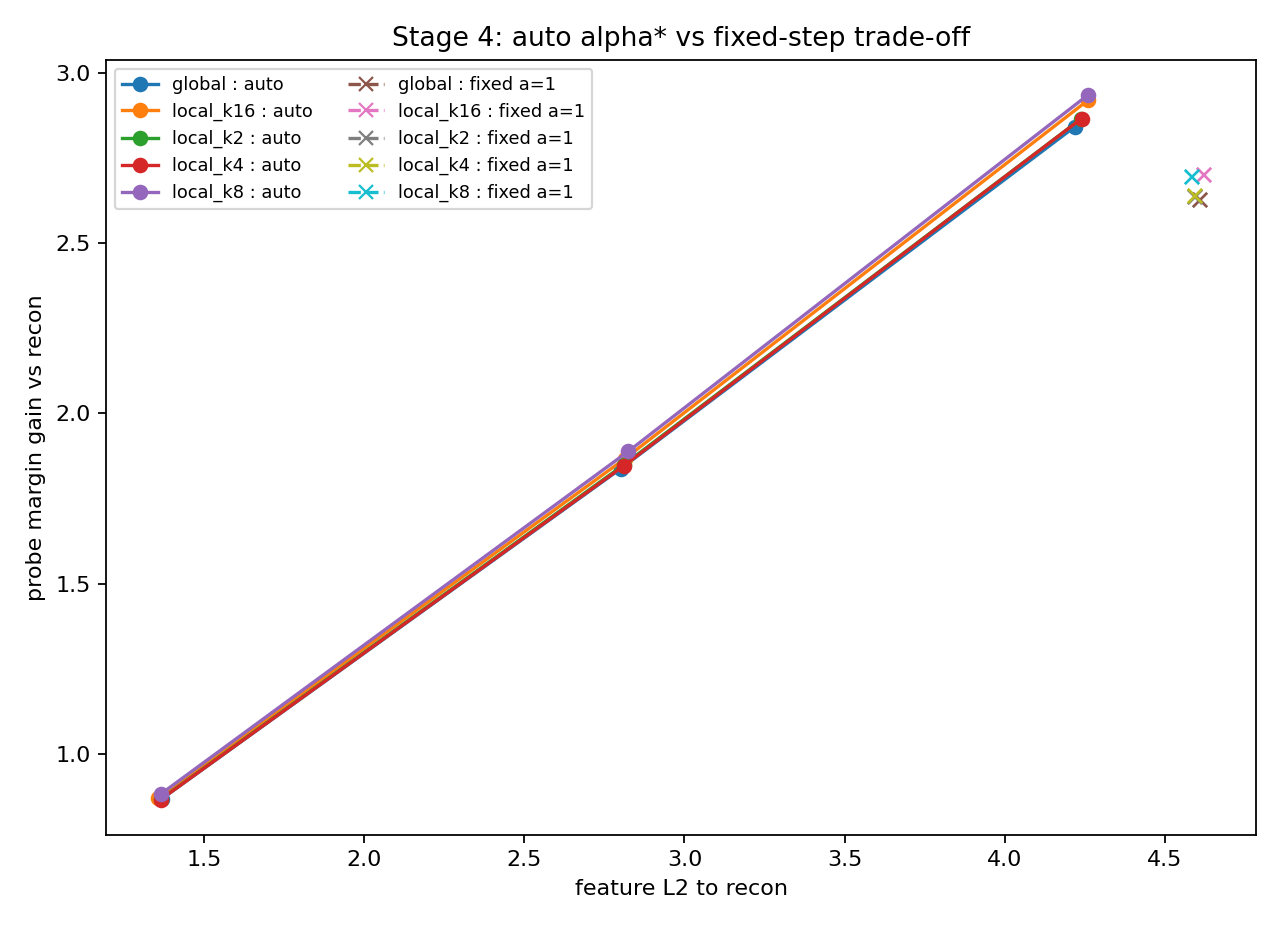

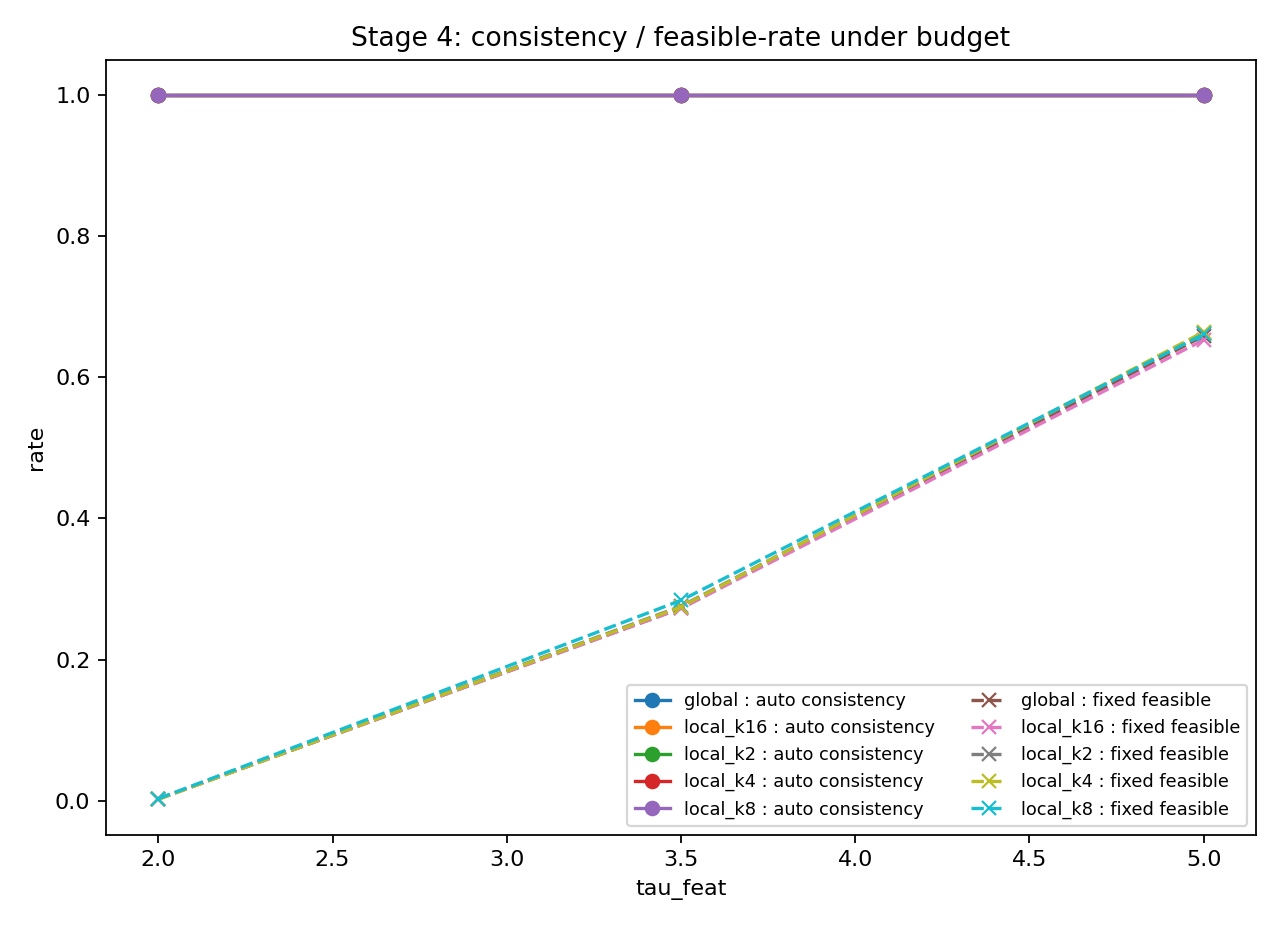

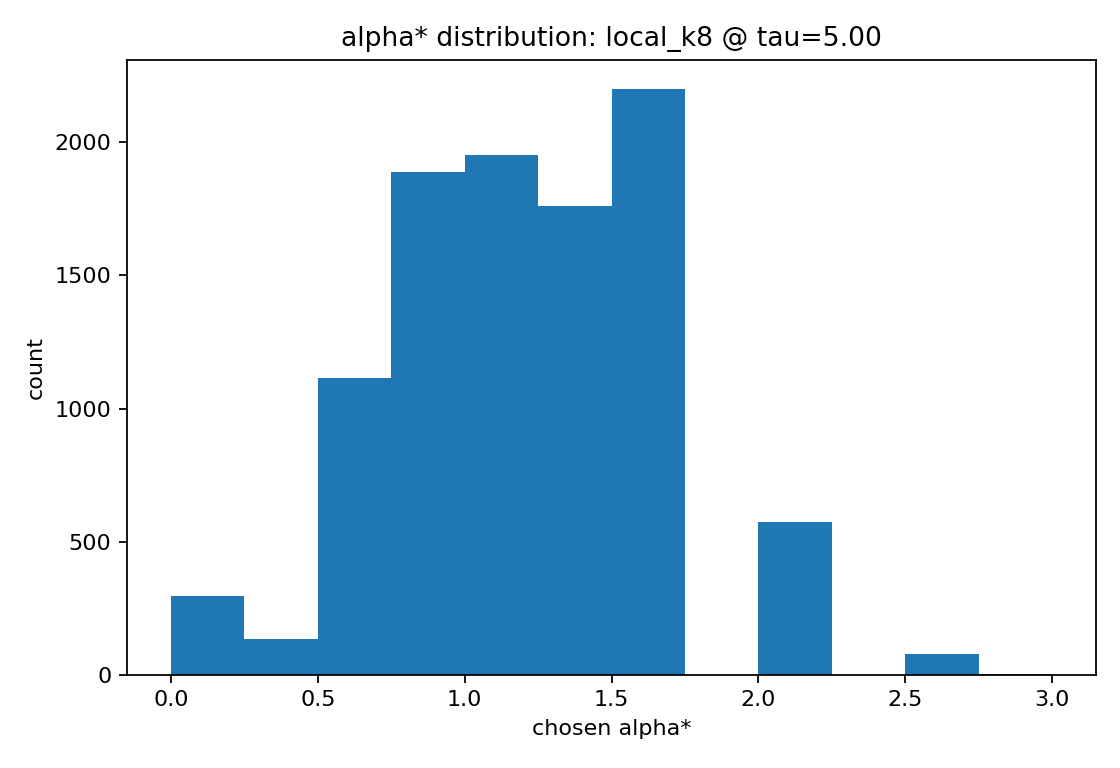

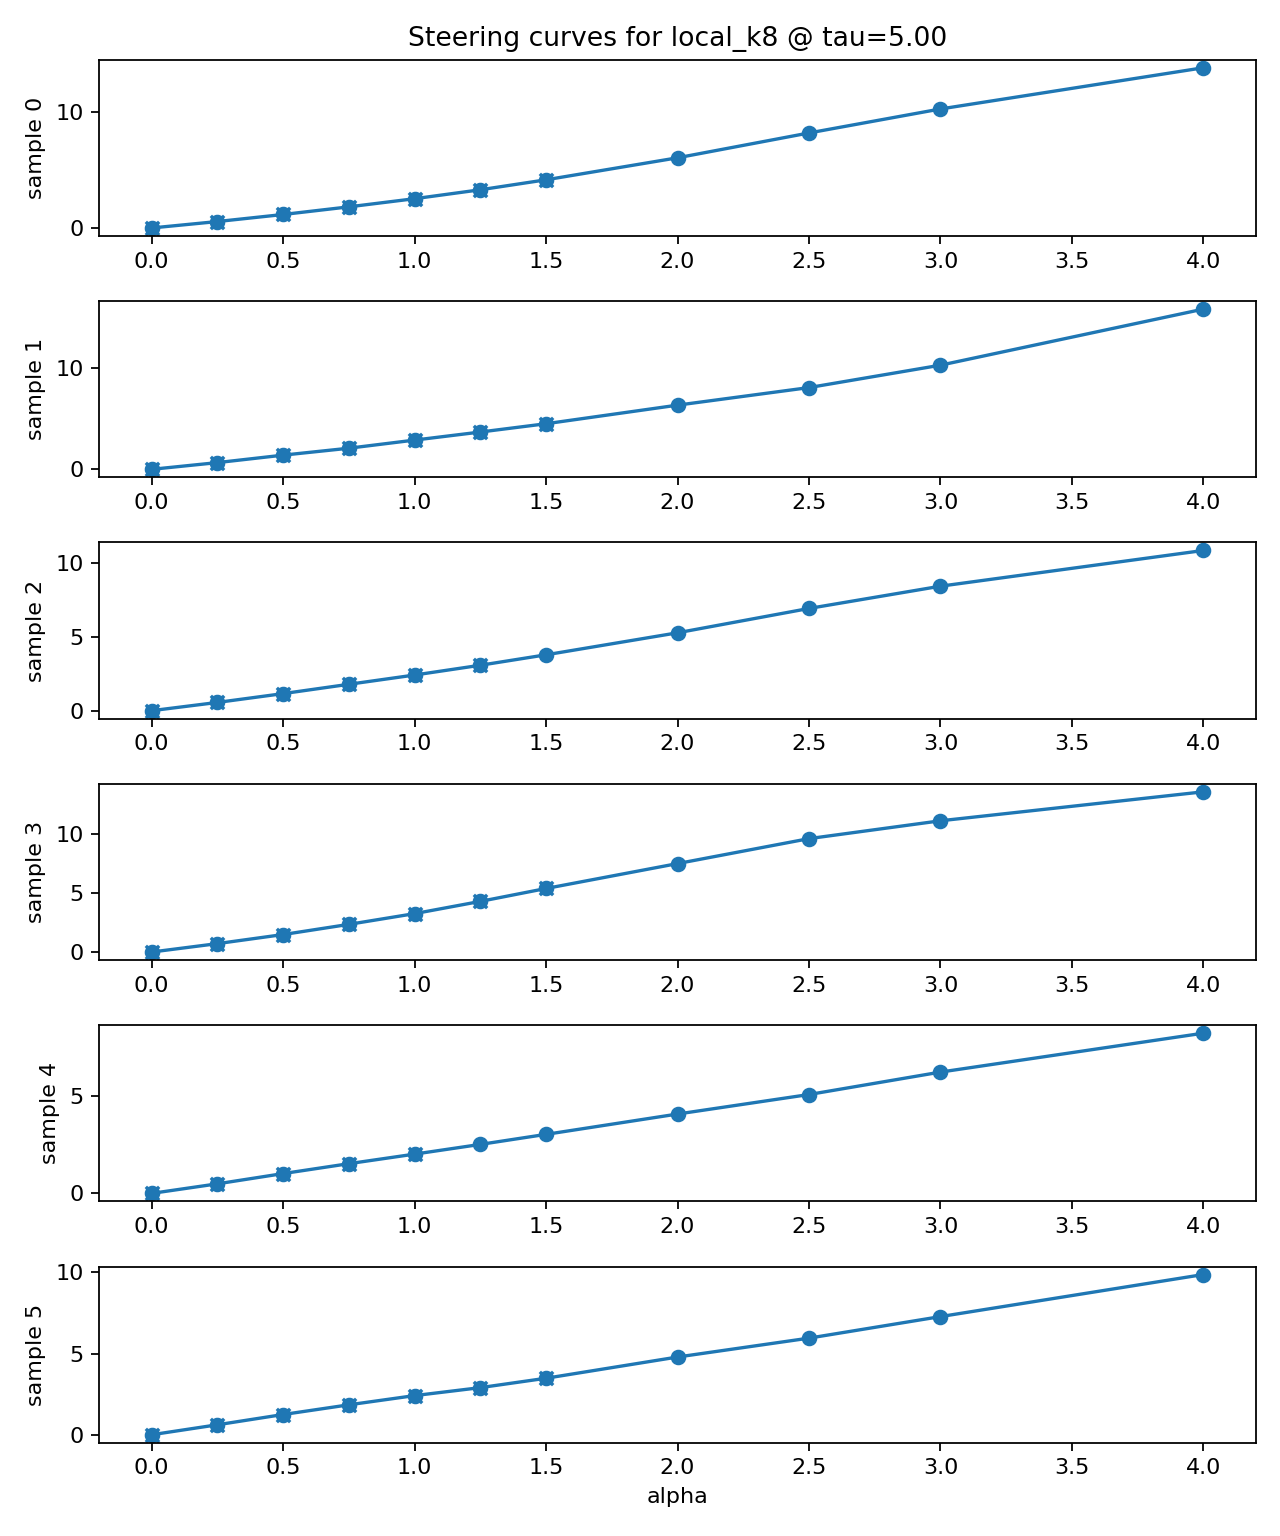

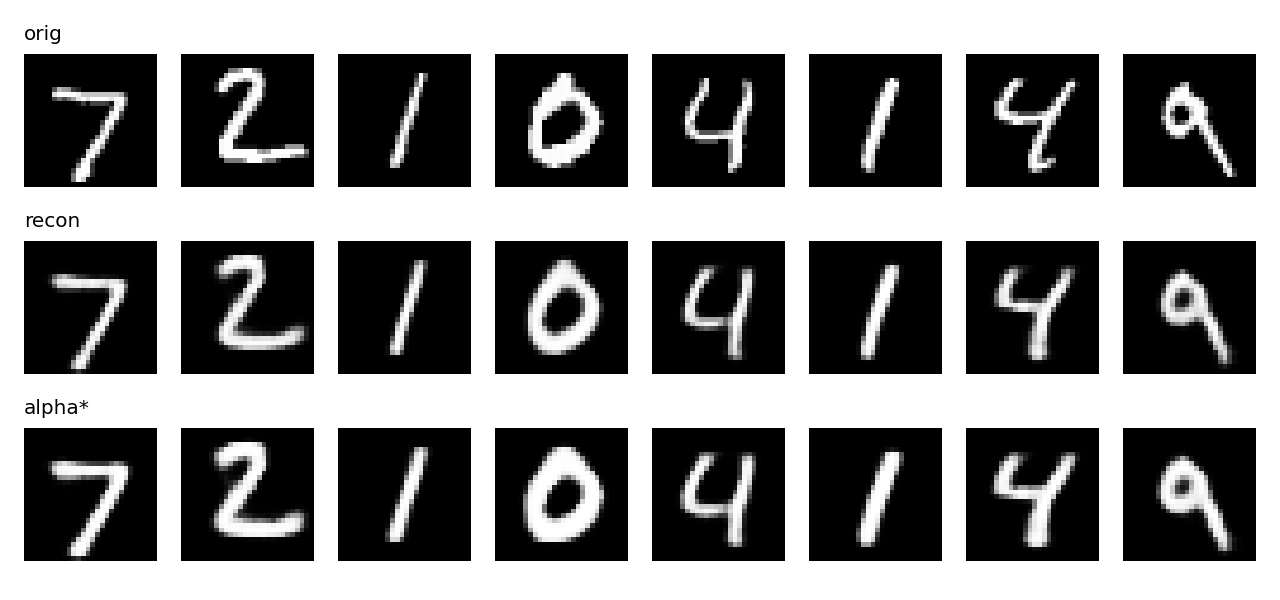

In [14]:

# Optional: show the key plots that were saved to disk
plot_dir = os.path.join(run_dir, "plots")
for name in [
    "auto_vs_fixed_tradeoff.png",
    "auto_vs_fixed_consistency.png",
    "alpha_star_hist_best.png",
    "steering_curves_best.png",
    "preview_alpha_star_best.png",
]:
    p = os.path.join(plot_dir, name)
    if os.path.exists(p):
        display(Image(filename=p))
